In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import files
upload = files.upload()

Saving growth_trends.csv to growth_trends.csv
Saving product_sales.csv to product_sales.csv
Saving state_revenue.csv to state_revenue.csv
Saving delivery_reviews.csv to delivery_reviews.csv
Saving payment_trends.csv to payment_trends.csv
Saving cohort_results.csv to cohort_results.csv
Saving rfm_results.csv to rfm_results.csv


In [ ]:
df_rfm = pd.read_csv('rfm_results.csv')
df_cohort = pd.read_csv('cohort_results.csv')
df_payments = pd.read_csv('payment_trends.csv')
df_delivery = pd.read_csv('delivery_reviews.csv')
df_state = pd.read_csv('state_revenue.csv')
df_products = pd.read_csv('product_sales.csv')
df_growth = pd.read_csv('growth_trends.csv')


In [ ]:
df_rfm.head()

,customer_id,recency,frequency,monetary,segment
0,355077684019f7f60a031656bd7262b8,3622,1,45.46,Lost
1,7ec40b22510fdbea1b08921dd39e63d8,3622,1,39.09,Lost
2,7812fcebfc5e8065d31e1bb5f0017dae,3622,1,40.95,Lost
3,031f08a1ebdcfb5e706831bf64de3860,3620,1,71.20,Lost
4,b8cf418e97ae795672d326288dfab7a7,3622,1,133.46,Lost


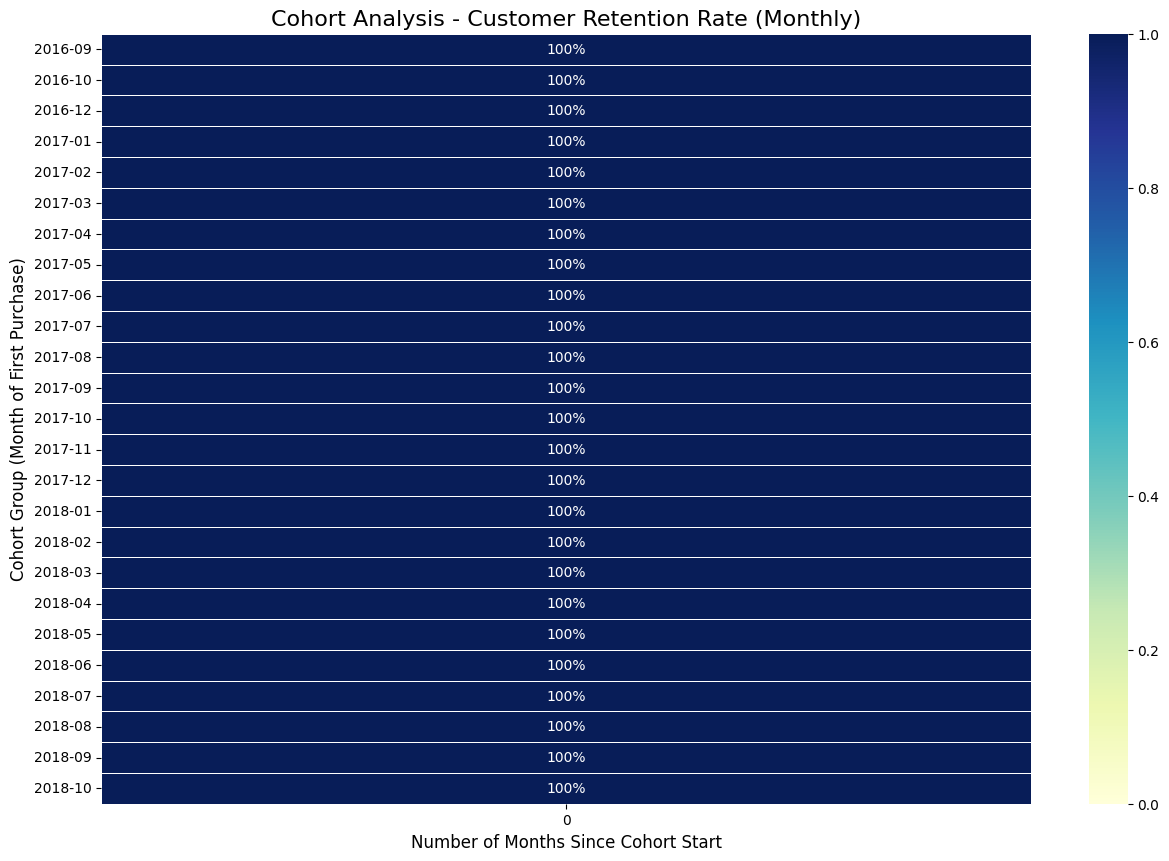

In [ ]:
df_cohort['cohort_month'] = pd.to_datetime(df_cohort['cohort_month'])

# Create a pivot table for the heatmap
cohort_pivot = df_cohort.pivot_table(
    index='cohort_month',
    columns='month_number',
    values='active_customers'
)

# Calculate retention rate relative to the initial cohort size
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

# Format the index for better readability
retention_matrix.index = retention_matrix.index.strftime('%Y-%m')

plt.figure(figsize=(15, 10))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.0%',
    cmap='YlGnBu',
    vmin=0.0,
    vmax=1.0,
    linewidths=0.5,
    linecolor='white'
)
plt.title('Cohort Analysis - Customer Retention Rate (Monthly)', fontsize=16)
plt.xlabel('Number of Months Since Cohort Start', fontsize=12)
plt.ylabel('Cohort Group (Month of First Purchase)', fontsize=12)
plt.yticks(rotation=0)
plt.show()

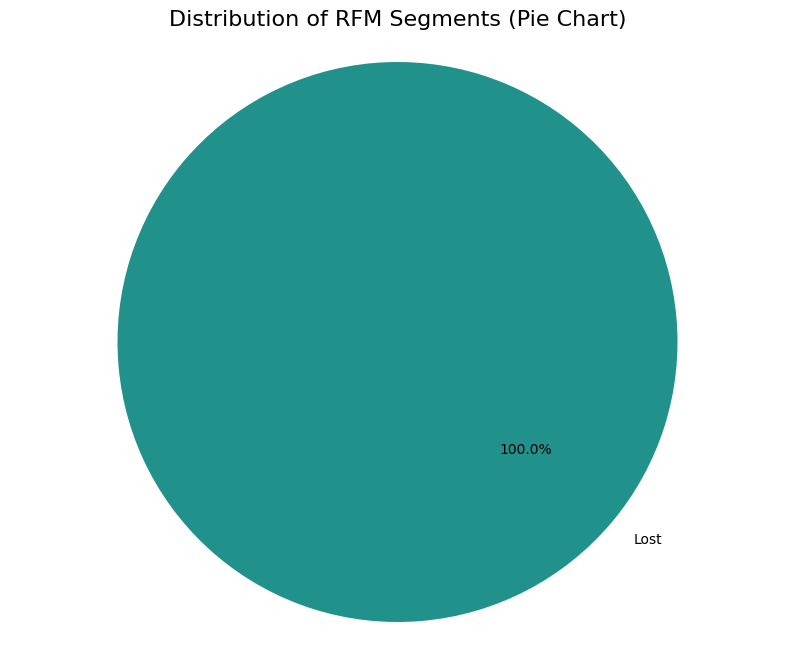

In [ ]:
segment_counts = df_rfm['segment'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(segment_counts)))
plt.title('Distribution of RFM Segments (Pie Chart)', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

/tmp/ipykernel_2044/3176339388.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')


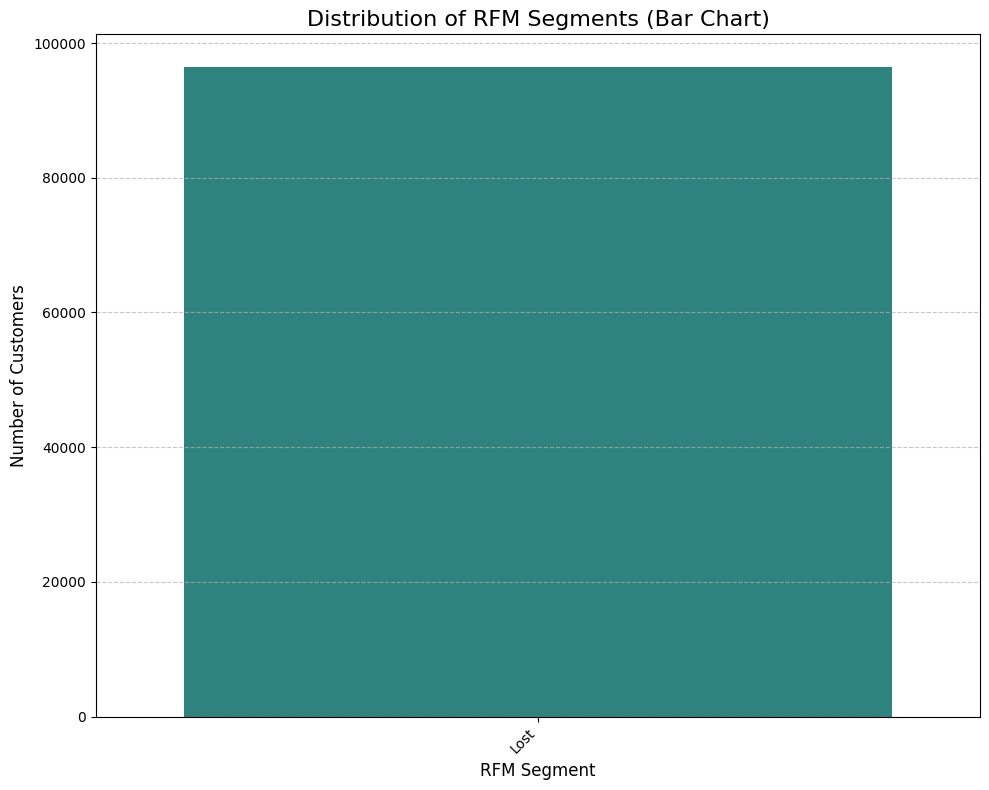

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')
plt.title('Distribution of RFM Segments (Bar Chart)', fontsize=16)
plt.xlabel('RFM Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

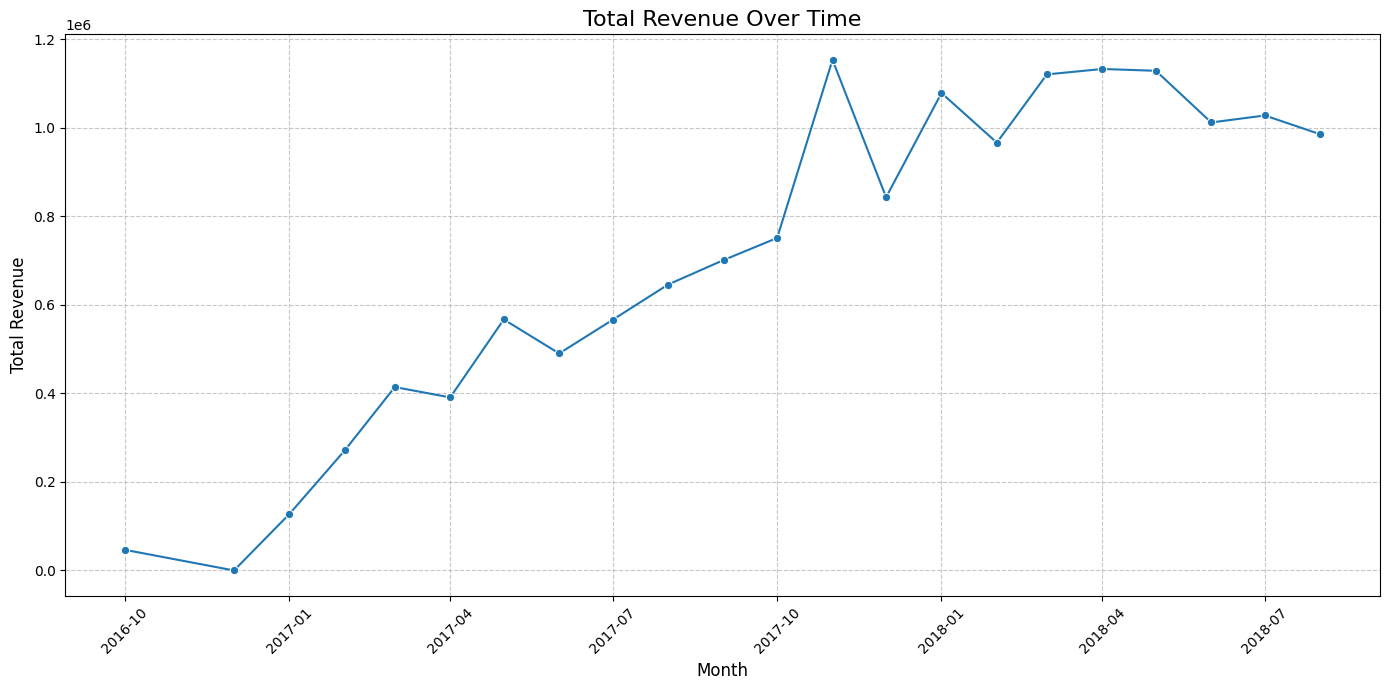

In [ ]:
df_growth['month'] = pd.to_datetime(df_growth['month'])

plt.figure(figsize=(14, 7))
sns.lineplot(x='month', y='total_revenue', data=df_growth, marker='o')
plt.title('Total Revenue Over Time', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print(len(df_growth_ts))


23


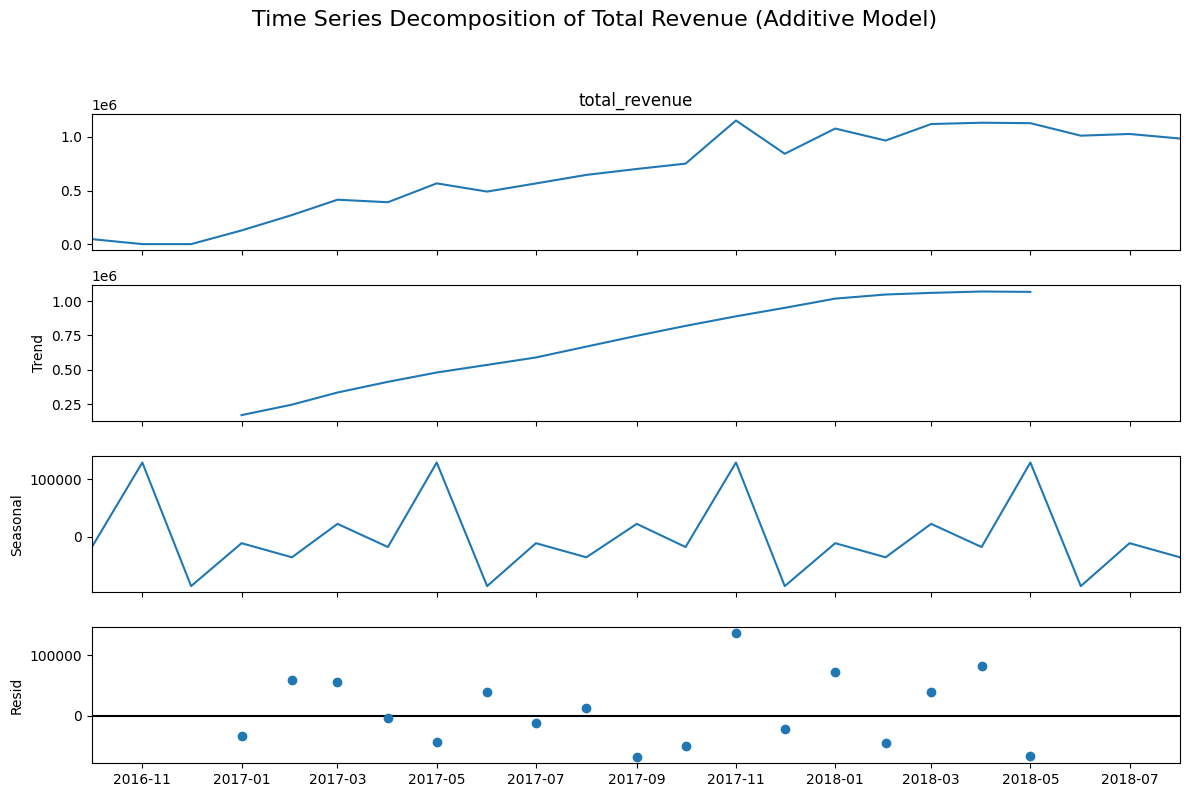

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set 'month' as the index for time series decomposition
df_growth_ts = df_growth.set_index('month')

# Resample to monthly frequency if not already (important for decomposition)
df_growth_ts = df_growth_ts['total_revenue'].resample('MS').sum()

# Perform seasonal decomposition
decomposition = seasonal_decompose(df_growth_ts, model='additive', period=6)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition of Total Revenue (Additive Model)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

/tmp/ipykernel_2044/2698844694.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_state', y='total_revenue', data=df_state_sorted, palette='viridis')


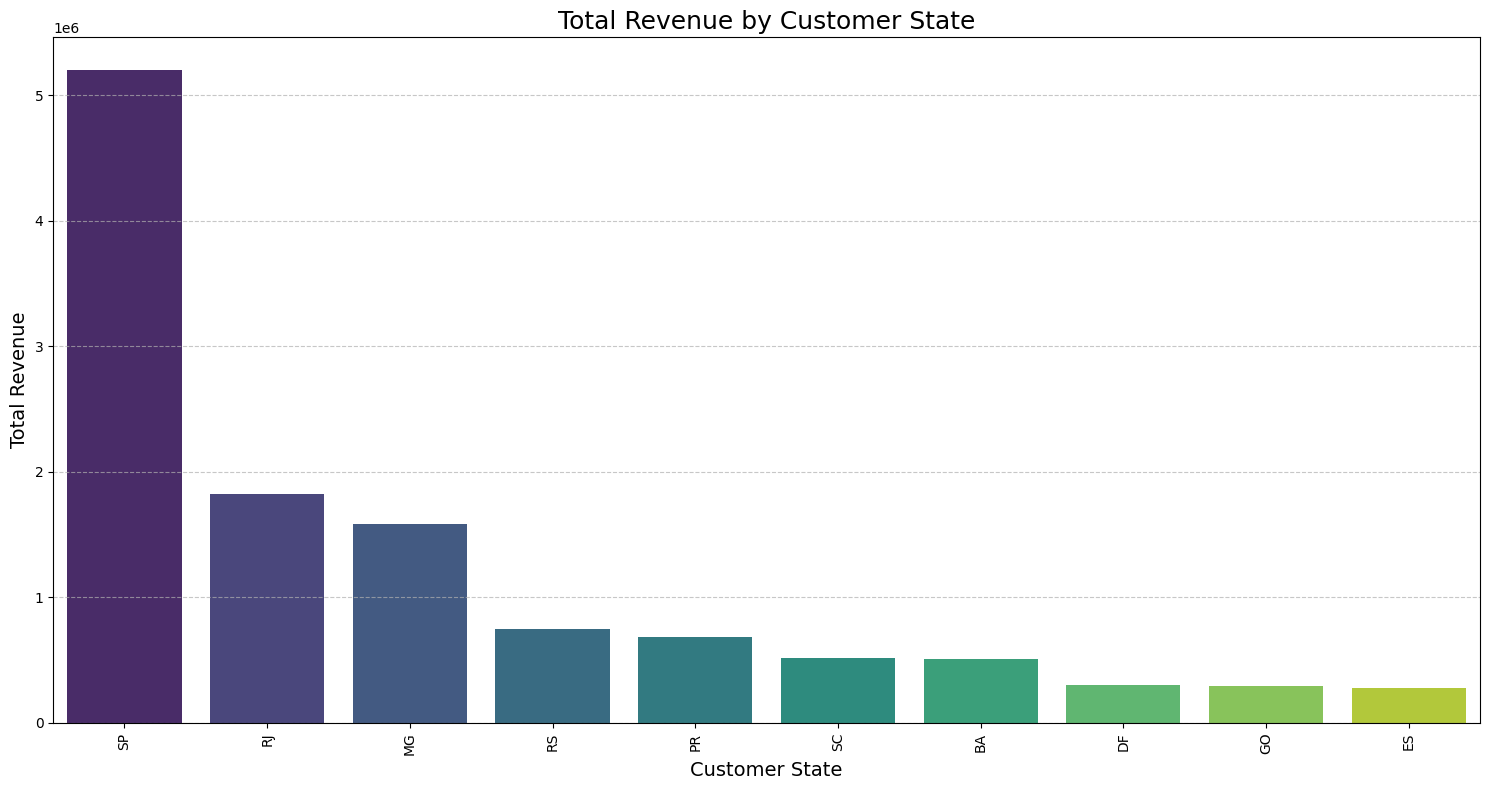

In [ ]:
# Sort the DataFrame by total_revenue for better visualization
df_state_sorted = df_state.sort_values(by='total_revenue', ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x='customer_state', y='total_revenue', data=df_state_sorted, palette='viridis')
plt.title('Total Revenue by Customer State', fontsize=18)
plt.xlabel('Customer State', fontsize=14)
plt.ylabel('Total Revenue', fontsize=14)
plt.xticks(rotation=90) # Rotate state names for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

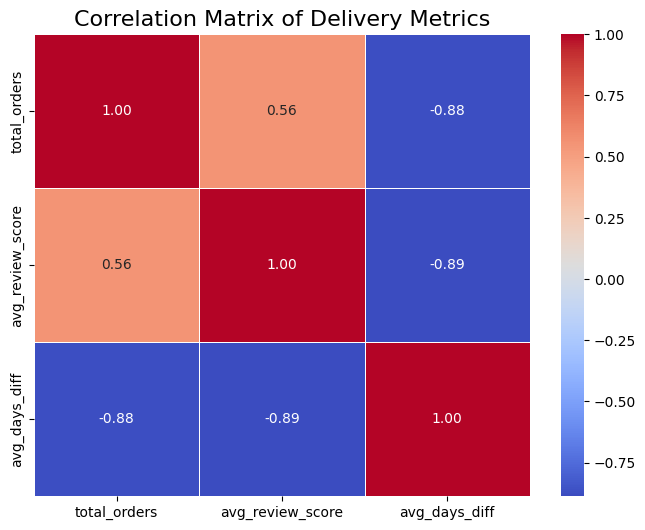

In [ ]:
# Select numerical columns for correlation analysis
delivery_numeric = df_delivery[['total_orders', 'avg_review_score', 'avg_days_diff']]

# Calculate the correlation matrix
correlation_matrix = delivery_numeric.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Delivery Metrics', fontsize=16)
plt.show()